<a href="https://colab.research.google.com/github/AhmedMagherbi/football-match-analysis/blob/main/01_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("pandas", pd.__version__)
print("Tout est prêt !")


pandas 2.2.3
Tout est prêt !


In [7]:
seasons = ["1516","1617","1718","1819","1920","2021","2122","2223","2324","2425"]
cols = ["Date","HomeTeam","AwayTeam","FTHG","FTAG","FTR",
        "HS","AS","HST","AST","HF","AF","HC","AC","HY","AY","HR","AR"]

frames = []
for s in seasons:
    url = f"https://www.football-data.co.uk/mmz4281/{s}/E0.csv"
    d = pd.read_csv(url)[cols]
    d["Season"] = s
    frames.append(d)

df = pd.concat(frames, ignore_index=True)
df = df.dropna(subset=["FTR"])
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, format="mixed")
df = df.sort_values("Date").reset_index(drop=True)
df.head()


,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HS,AS,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR,Season
0,2015-08-08,Bournemouth,Aston Villa,0,1,A,11,7,2,3,13,13,6,3,3,4,0,0,1516
1,2015-08-08,Chelsea,Swansea,2,2,D,11,18,3,10,15,16,4,8,1,3,1,0,1516
2,2015-08-08,Everton,Watford,2,2,D,10,11,5,5,7,13,8,2,1,2,0,0,1516
3,2015-08-08,Leicester,Sunderland,4,2,H,19,10,8,5,13,17,6,3,2,4,0,0,1516
4,2015-08-08,Man United,Tottenham,1,0,H,9,9,1,4,12,12,1,2,2,3,0,0,1516


In [8]:
df.info()
print(df.isna().sum())
print("Doublons :", df.duplicated().sum())
print(df["FTR"].value_counts(normalize=True))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3800 entries, 0 to 3799
Data columns (total 19 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      3800 non-null   datetime64[ns]
 1   HomeTeam  3800 non-null   object        
 2   AwayTeam  3800 non-null   object        
 3   FTHG      3800 non-null   int64         
 4   FTAG      3800 non-null   int64         
 5   FTR       3800 non-null   object        
 6   HS        3800 non-null   int64         
 7   AS        3800 non-null   int64         
 8   HST       3800 non-null   int64         
 9   AST       3800 non-null   int64         
 10  HF        3800 non-null   int64         
 11  AF        3800 non-null   int64         
 12  HC        3800 non-null   int64         
 13  AC        3800 non-null   int64         
 14  HY        3800 non-null   int64         
 15  AY        3800 non-null   int64         
 16  HR        3800 non-null   int64         
 17  AR        3800

     shots_diff  sot_diff  corners_diff  fouls_diff  yellow_diff  red_diff
FTR                                                                       
A         -1.61     -2.07          0.30       -0.10         0.01      0.06
D          2.31      0.51          1.19       -0.39        -0.15     -0.02
H          5.38      2.93          1.41       -0.57        -0.32     -0.05


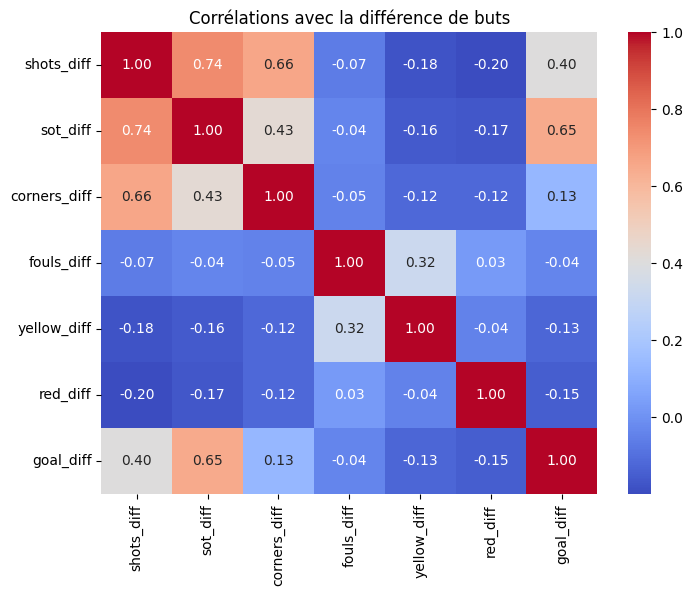

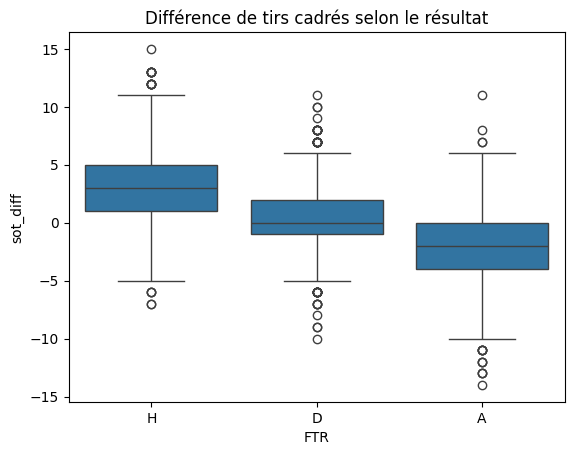

In [12]:
df["goal_diff"]    = df["FTHG"] - df["FTAG"]
df["shots_diff"]   = df["HS"]  - df["AS"]
df["sot_diff"]     = df["HST"] - df["AST"]
df["corners_diff"] = df["HC"]  - df["AC"]
df["fouls_diff"]   = df["HF"]  - df["AF"]
df["yellow_diff"]  = df["HY"]  - df["AY"]
df["red_diff"]     = df["HR"]  - df["AR"]

feats = ["shots_diff","sot_diff","corners_diff","fouls_diff","yellow_diff","red_diff"]

# 1) Moyenne de chaque indicateur selon le résultat
print(df.groupby("FTR")[feats].mean().round(2))

# 2) Corrélation avec la différence de buts
corr = df[feats + ["goal_diff"]].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Corrélations avec la différence de buts")
plt.show()

# 3) Tirs cadrés selon le résultat
sns.boxplot(data=df, x="FTR", y="sot_diff", order=["H","D","A"])
plt.title("Différence de tirs cadrés selon le résultat")
plt.show()

In [14]:
df.to_csv("matches.csv", index=False)
from google.colab import files
files.download("matches.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Baseline : 0.434

Régression logistique : accuracy = 0.604
              precision    recall  f1-score   support

           A       0.60      0.68      0.64       255
           D       0.38      0.02      0.03       175
           H       0.61      0.85      0.71       330

    accuracy                           0.60       760
   macro avg       0.53      0.52      0.46       760
weighted avg       0.55      0.60      0.53       760



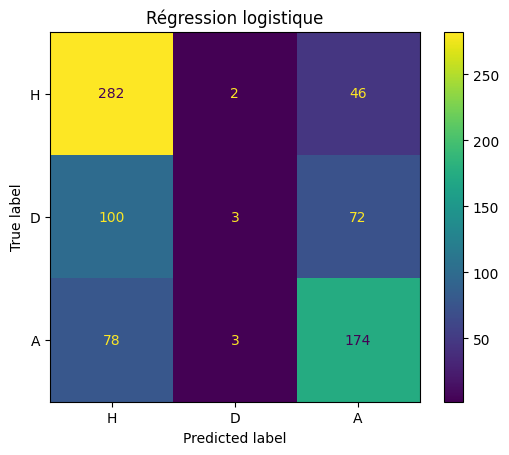


Random Forest : accuracy = 0.561
              precision    recall  f1-score   support

           A       0.61      0.60      0.60       255
           D       0.30      0.15      0.20       175
           H       0.59      0.75      0.66       330

    accuracy                           0.56       760
   macro avg       0.50      0.50      0.49       760
weighted avg       0.53      0.56      0.53       760



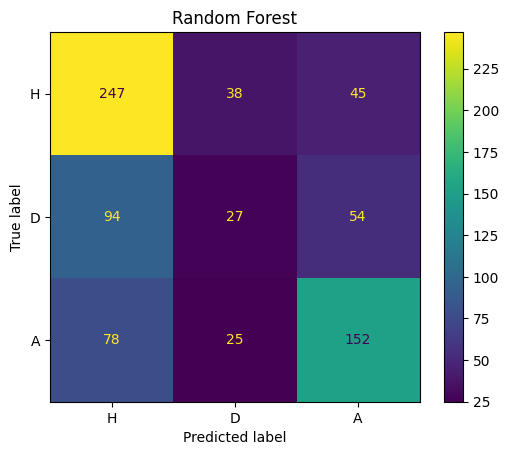

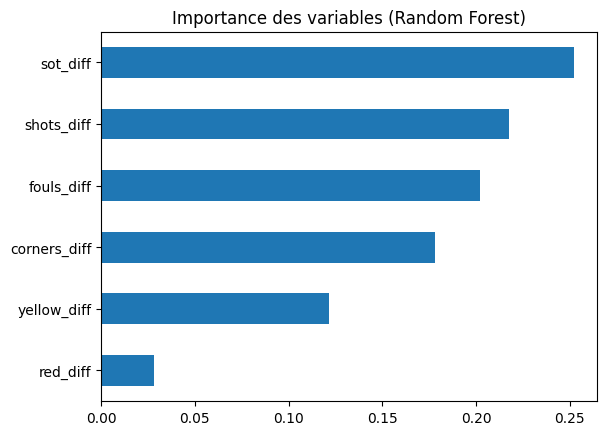

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

X, y = df[feats], df["FTR"]

# Découpage CHRONOLOGIQUE : 80 % du passé pour entraîner, 20 % du futur pour tester
cut = int(len(df) * 0.8)
X_train, X_test = X.iloc[:cut], X.iloc[cut:]
y_train, y_test = y.iloc[:cut], y.iloc[cut:]

# Référence : toujours prédire la classe la plus fréquente
baseline = y_train.value_counts().idxmax()
print("Baseline :", round((y_test == baseline).mean(), 3))

models = {
    "Régression logistique": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
}

for name, m in models.items():
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    print(f"\n{name} : accuracy = {accuracy_score(y_test, pred):.3f}")
    print(classification_report(y_test, pred))
    ConfusionMatrixDisplay(confusion_matrix(y_test, pred, labels=["H","D","A"]),
                           display_labels=["H","D","A"]).plot()
    plt.title(name); plt.show()

# Importance des variables
rf = models["Random Forest"]
pd.Series(rf.feature_importances_, index=feats).sort_values().plot.barh()
plt.title("Importance des variables (Random Forest)")
plt.show()